# Working with complicated dataset

In [ ]:
%autosave 60


Autosaving every 60 seconds


Your name: Sumit Shrestha

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [8]:
import pandas as pd
import urllib
import csv
blast_results = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"





In [9]:
my_cols = ["query acc.ver", "subject acc.ver", "% identity", "alignment length", "mismatches"," gap opens", "q. start"," q. end", "s. start",
           "s. end", "evalue", "bit score", "% positives", "bonds", "publications"]



blasts = pd.read_csv(
    blast_results,
    skiprows=7,
    header=None,
    names=my_cols,
    usecols=my_cols,
    engine="python",

)

blasts.drop(blasts.columns[0], axis=1, inplace=True)
blasts = blasts.set_index("subject acc.ver")
blasts.head(5)

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3


### Question 2
What is the average number of publications?

In [10]:
blasts["publications"]=pd.to_numeric(blasts["publications"], errors="coerce")


avg_publications = blasts["publications"].mean()
print(avg_publications)


26.989690721649485


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [11]:
blasts["bonds"] = blasts["bonds"].astype(str).str.replace(',','')
blasts["bonds"] = pd.to_numeric(blasts["bonds"], errors='coerce')
blasts["bonds"].dtype

blasts.reset_index(inplace=True)
over_15k = blasts.loc[blasts["bonds"] > 15000, "subject acc.ver"]
print(over_15k)


1         AGK29621.1
4         AHG32084.1
6             6G2J_H
12    YP_002791042.1
17        AGK29634.1
18          0806162F
21    YP_009112408.1
22    YP_001876469.1
24    YP_009092269.1
25        AHG32149.1
26    YP_009092074.1
27    YP_009450474.1
30    YP_004123270.1
31    YP_009092073.1
32        AHZ60901.1
40    YP_004123350.1
42    YP_009453754.1
44        ADD46492.1
46    YP_007025968.1
50    YP_009453806.1
52    YP_007024956.1
58        ASM92364.1
62    YP_006073044.1
63        ASM92494.1
64        ADG95699.1
68    YP_004891275.1
72    YP_009166014.1
82    YP_009538416.1
84    YP_009414182.1
85    YP_009178854.1
87    YP_009414415.1
89    YP_009353908.1
92    YP_009093743.1
95        ABX45285.1
97    YP_009414156.1
98    YP_009414363.1
Name: subject acc.ver, dtype: object


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

Text(0.5, 1.0, 'Relation between % identity and % positives')

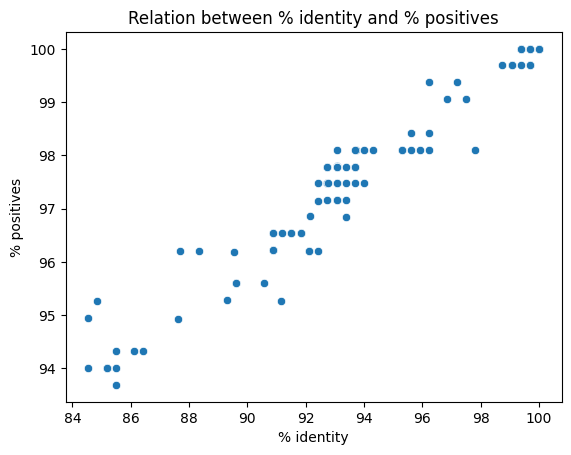

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.scatterplot(
    data = blasts,
    x="% identity",
    y="% positives"
)

plt.title("Relation between % identity and % positives")

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [17]:

protein_source_file = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
protein = pd.read_csv(protein_source_file)


blasts5 = blasts.merge(
    protein[["Protein", "Source"]],
    how="left",
    left_on="subject acc.ver",
    right_on="Protein"
)

blasts5 = blasts5.drop(columns=["Protein"]).rename(columns={"Source": "Protein source"})
# blasts5 = blasts5.set_index("subject acc.ver")
blasts5.head()



,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
subject acc.ver,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NaN
